In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import shap
shap.initjs()
import lime.lime_tabular
import warnings
warnings.filterwarnings("ignore")

# Załaduj dane
df = pd.read_csv("titanic.csv")
df.drop(['Name', 'Ticket', 'Cabin', 'PassengerId'], axis=1, inplace=True)
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Podział na cechy i etykiety
X = df.drop("Survived", axis=1)
y = df["Survived"]

num_features = ['Age', 'SibSp', 'Parch', 'Fare']
cat_features = ['Sex', 'Embarked', 'Pclass']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=4),
    'SVC': SVC(probability=True)
}

pipelines = {}
scores = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)
    pipelines[name] = pipeline
    scores[name] = pipeline.score(X_test, y_test)

# Wyniki
print("📊 Wyniki dokładności modeli:")
for name, score in scores.items():
    print(f"{name}: {score:.3f}")


📊 Wyniki dokładności modeli:
Logistic Regression: 0.799
KNN: 0.810
Decision Tree: 0.799
SVC: 0.816



🔎 Logistic Regression — Obserwacja 0

SHAP Waterfall Plot - Logistic Regression - Obserwacja 0





LIME Feature Importance - wyjaśnienie lokalne cech dla danej obserwacji


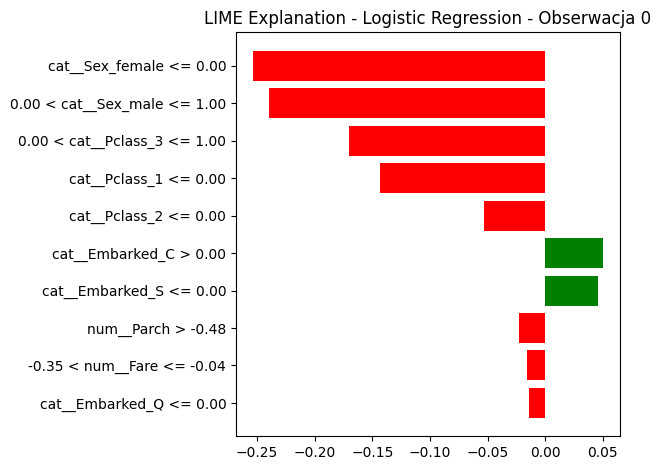


🔎 KNN — Obserwacja 0

SHAP Waterfall Plot - KNN - Obserwacja 0



LIME Feature Importance - wyjaśnienie lokalne cech dla danej obserwacji


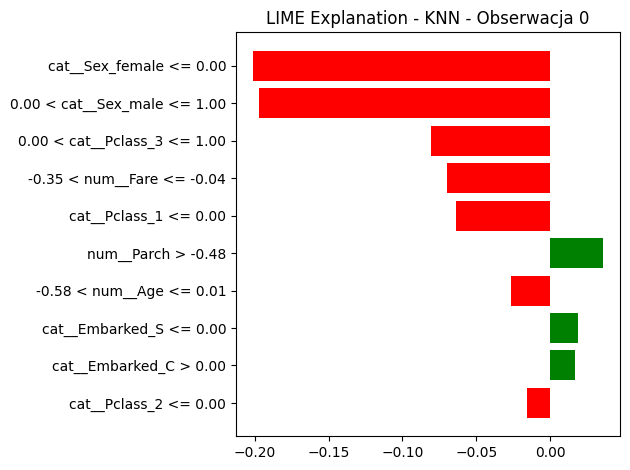


🔎 Decision Tree — Obserwacja 0

SHAP Waterfall Plot - Decision Tree - Obserwacja 0





LIME Feature Importance - wyjaśnienie lokalne cech dla danej obserwacji


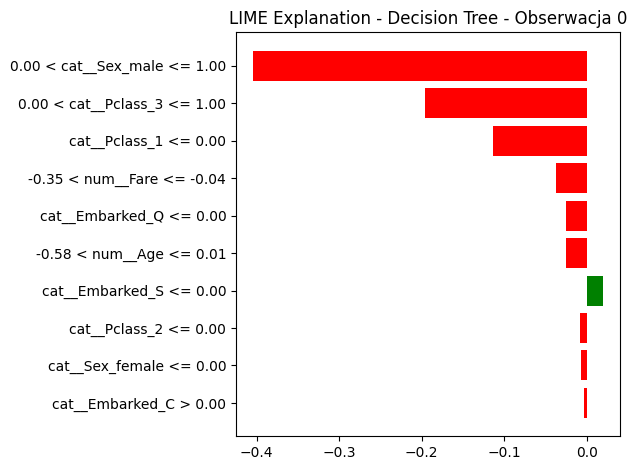


🔎 SVC — Obserwacja 0

SHAP Waterfall Plot - SVC - Obserwacja 0



LIME Feature Importance - wyjaśnienie lokalne cech dla danej obserwacji


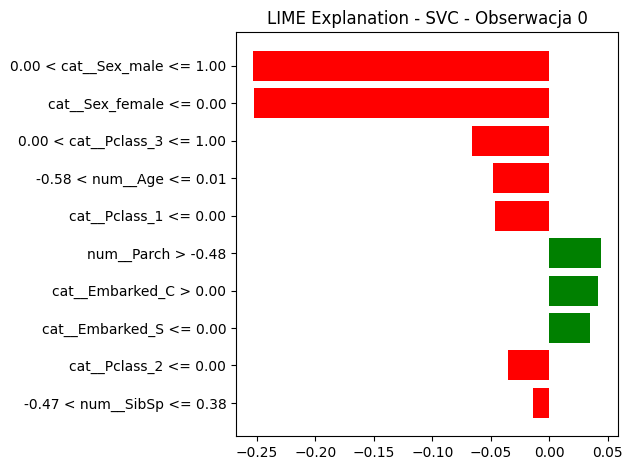

In [27]:
from IPython.display import display
import matplotlib.pyplot as plt

def explain_local(model_name, index=0):
    print(f"\n🔎 {model_name} — Obserwacja {index}")
    pipeline = pipelines[model_name]
    
    sample = X_test.iloc[[index]]
    sample_pre = pipeline.named_steps['preprocessor'].transform(sample)
    sample_array = sample_pre.toarray() if hasattr(sample_pre, "toarray") else sample_pre
    
    # === SHAP ===
    model = pipeline.named_steps['classifier']
    explainer = shap.Explainer(model.predict_proba, sample_pre)
    shap_values = explainer(sample_pre)
    
    print(f"\nSHAP Waterfall Plot - {model_name} - Obserwacja {index}")
    shap.plots.waterfall(shap.Explanation(
        values=shap_values.values[0][:, 1],
        base_values=shap_values.base_values[0][1],
        data=shap_values.data[0],
        feature_names=pipeline.named_steps['preprocessor'].get_feature_names_out()
    ), max_display=10)
    # Nie dodajemy plt.title() ani plt.show() tutaj

    
    # === LIME ===
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=(preprocessor.fit_transform(X_train).toarray()
                       if hasattr(preprocessor.fit_transform(X_train), 'toarray')
                       else preprocessor.fit_transform(X_train)),
        feature_names=pipeline.named_steps['preprocessor'].get_feature_names_out(),
        class_names=['Not Survived', 'Survived'],
        mode='classification'
    )
    
    exp = lime_explainer.explain_instance(
        sample_array[0],
        model.predict_proba,
        num_features=10
    )
    
    print("\nLIME Feature Importance - wyjaśnienie lokalne cech dla danej obserwacji")
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Explanation - {model_name} - Obserwacja {index}")
    plt.tight_layout()
    plt.show()

# Przykład dla każdego modelu
for model_name in models:
    explain_local(model_name, index=0)


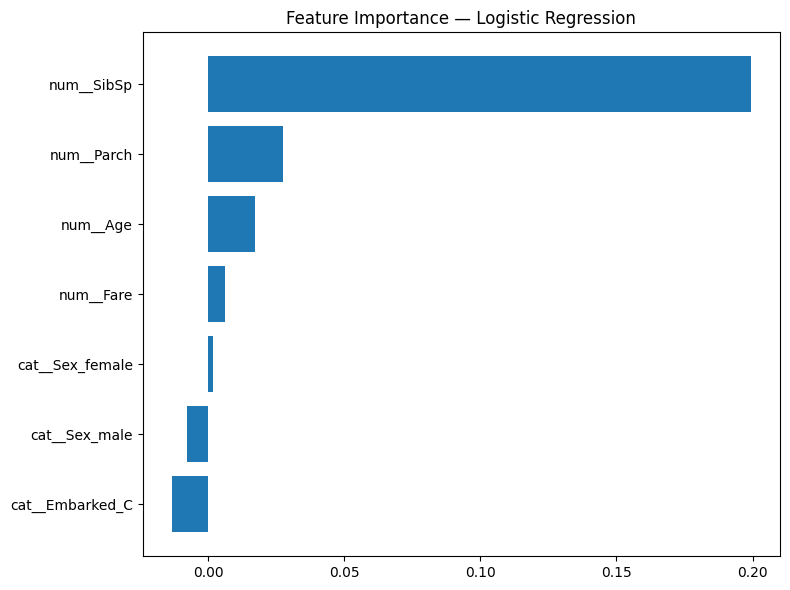

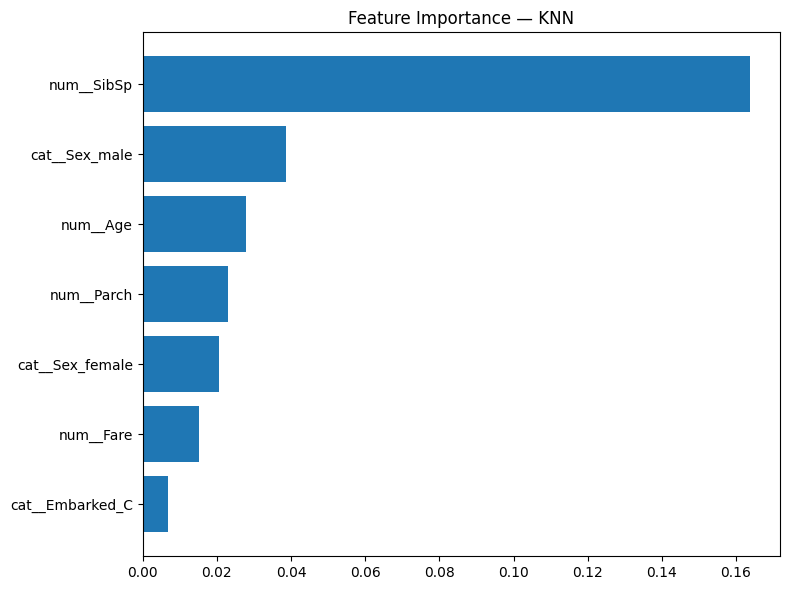

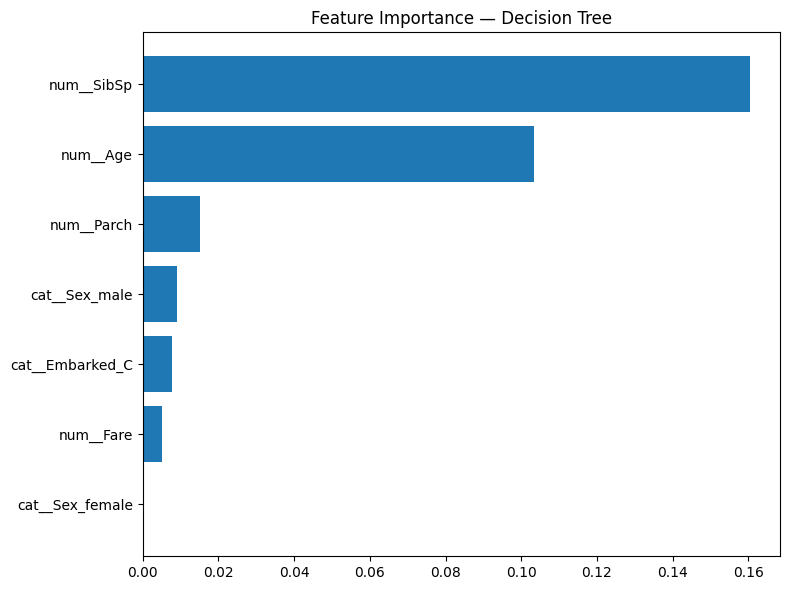

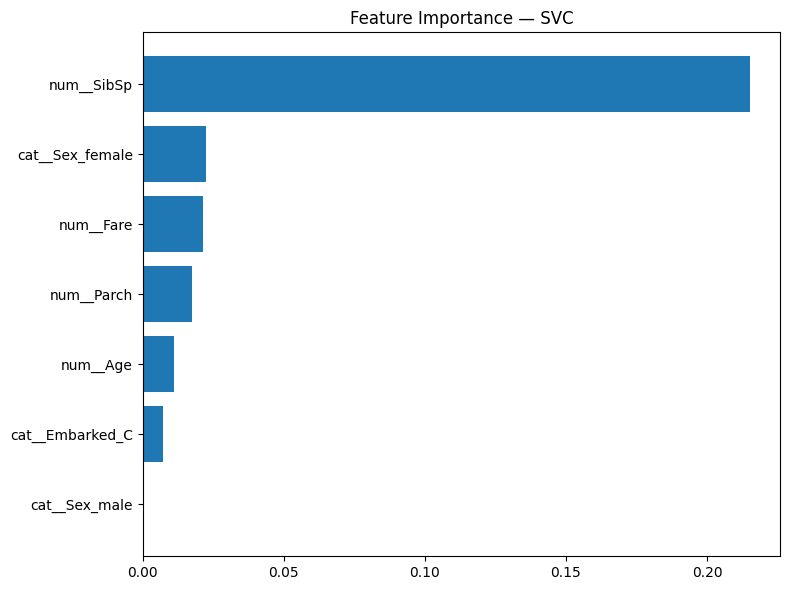

In [28]:
def plot_feature_importance(model_name):
    model = pipelines[model_name]
    result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
    sorted_idx = result.importances_mean.argsort()
    feature_names = model.named_steps['preprocessor'].get_feature_names_out()

    plt.figure(figsize=(8, 6))
    plt.barh(np.array(feature_names)[sorted_idx], result.importances_mean[sorted_idx])
    plt.title(f"Feature Importance — {model_name}")
    plt.tight_layout()
    plt.show()

for model_name in models:
    plot_feature_importance(model_name)


Partial Dependence — Logistic Regression


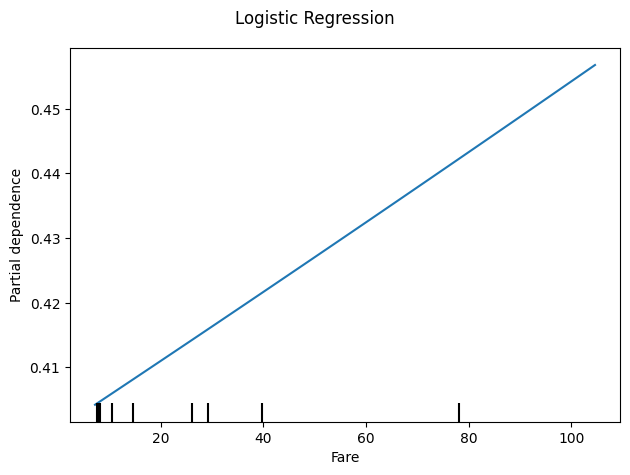

Partial Dependence — KNN


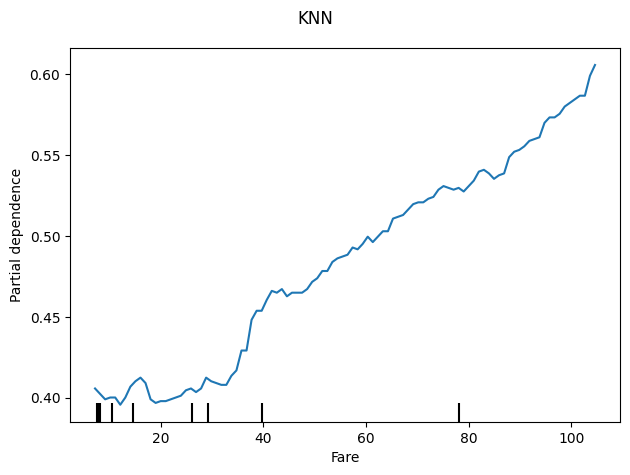

Partial Dependence — Decision Tree


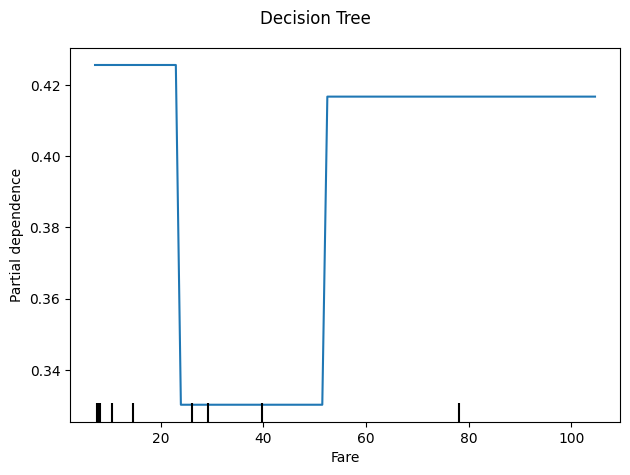

Partial Dependence — SVC


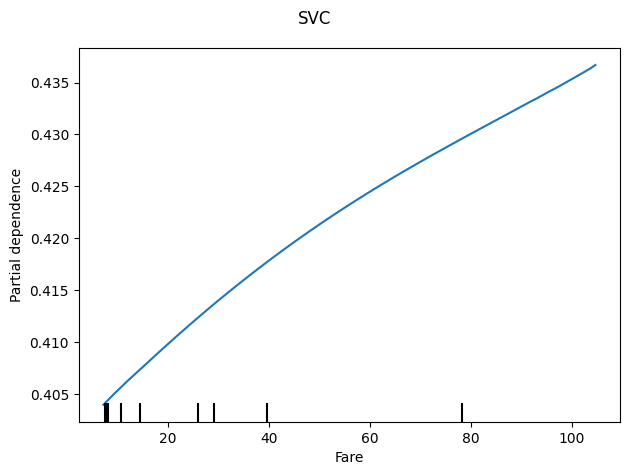

In [29]:
for model_name in models:
    print(f"Partial Dependence — {model_name}")
    PartialDependenceDisplay.from_estimator(pipelines[model_name], X_test, features=['Fare'])
    plt.suptitle(model_name)
    plt.tight_layout()
    plt.show()
